***EX NO 4 - PROBABLISTIC CLASSIFICATION USING NAIVE BAYES (GAUSSIAN & MULTINOMIAL NAIVE BAYES)***

**DATE: 13.02.2026**

**-SREENIDHI S (24BAD114)**

SCENARIO 1 – MULTINOMIAL NAÏVE BAYES

Problem Statement: Classify SMS messages as Spam or Ham (Not Spam)..
Dataset (Kaggle – Public) https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Target Variable: Message Label (Spam / Ham)
Input Feature: SMS Text Messages

IN-LAB TASKS (Multinomial Naïve Bayes)
1. Import required Python libraries.
2. Load the SMS Spam dataset.
3. Perform data preprocessing:
· Text cleaning (lowercase, punctuation removal)
· Stopword removal (optional)
4. Convert text into numerical features using:
· Count Vectorization / TF-IDF
5. Encode target labels.
6. Split dataset into training and testing sets.
7. Train a Multinomial Naïve Bayes classifier.
8. Predict message classes.
9. Evaluate performance using:
· Accuracy
· Precision
· Recall
· F1 Score
10. Analyze misclassified examples.
11. Apply Laplace smoothing and observe impact.
Visualization
• Confusion Matrix
• Feature importance (Top words influencing spam classification)
• Word frequency comparison (Spam vs Ham)

SREENIDHI-24BAD114


Saving spam.csv to spam.csv
MODEL EVALUATION
Accuracy : 0.9704035874439462
Precision: 0.8580246913580247
Recall   : 0.9328859060402684
F1 Score : 0.8938906752411575

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.86      0.93      0.89       149

    accuracy                           0.97      1115
   macro avg       0.92      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



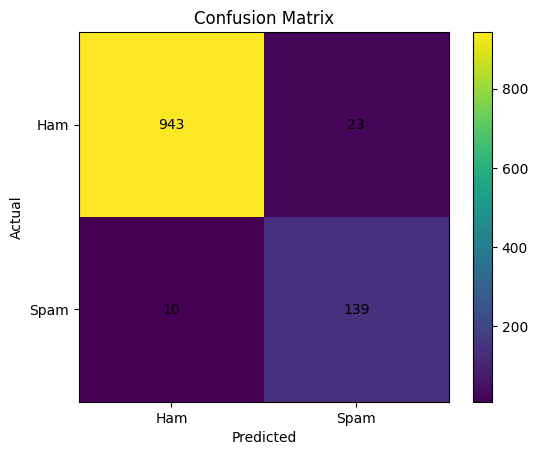


MISCLASSIFIED MESSAGES
Message: ringtoneking 84484
Actual: spam
Predicted: ham
--------------------------------------------------
Message: Sorry I missed your call let's talk when you have the time. I'm on 07090201529
Actual: spam
Predicted: ham
--------------------------------------------------
Message: Reverse is cheating. That is not mathematics.
Actual: ham
Predicted: spam
--------------------------------------------------
Message: Check mail.i have mailed varma and kept copy to you regarding membership.take care.insha allah.
Actual: ham
Predicted: spam
--------------------------------------------------
Message: Cps is causing the outages to conserve energy.
Actual: ham
Predicted: spam
--------------------------------------------------
Message: Ultimately tor motive tui achieve korli.
Actual: ham
Predicted: spam
--------------------------------------------------
Message: Can U get 2 phone NOW? I wanna chat 2 set up meet Call me NOW on 09096102316 U can cum here 2moro Luv JANE xx C

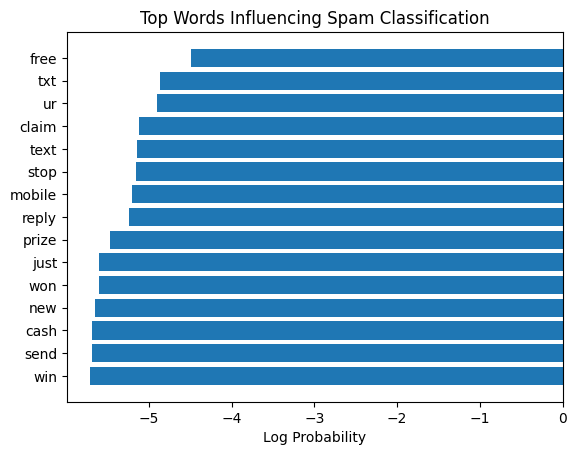

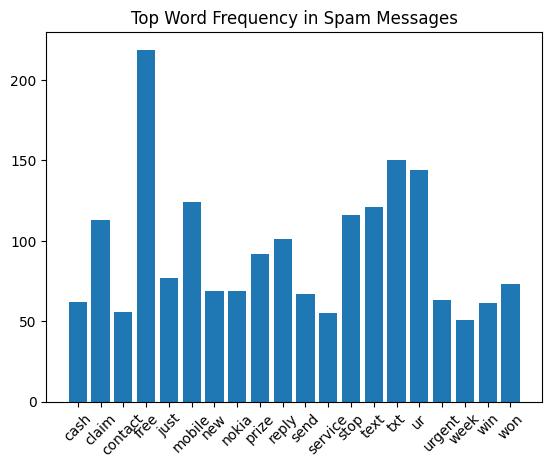

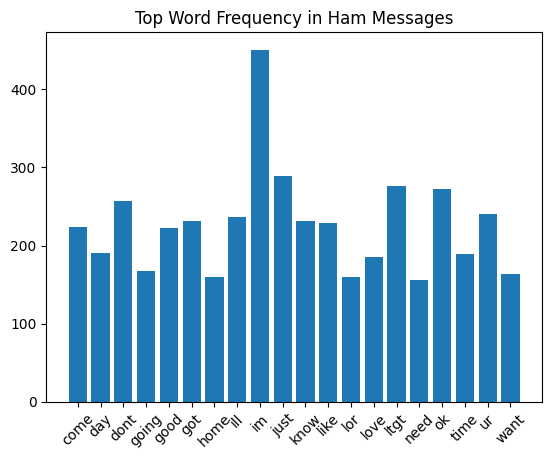


Accuracy WITHOUT Laplace Smoothing: 0.9614349775784753
[[940  26]
 [ 17 132]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       966
           1       0.84      0.89      0.86       149

    accuracy                           0.96      1115
   macro avg       0.91      0.93      0.92      1115
weighted avg       0.96      0.96      0.96      1115

Accuracy WITH Laplace Smoothing: 0.9704035874439462
[[943  23]
 [ 10 139]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       966
           1       0.86      0.93      0.89       149

    accuracy                           0.97      1115
   macro avg       0.92      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [1]:
print("SREENIDHI-24BAD114")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv("/content/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df["clean_message"] = df["message"].apply(clean_text)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["clean_message"])

encoder = LabelEncoder()
y = encoder.fit_transform(df["label"])

X_train, X_test, y_train, y_test, msg_train, msg_test = train_test_split(
    X, y, df["message"], test_size=0.2, random_state=42, stratify=y)

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Ham','Spam'])
plt.yticks([0,1], ['Ham','Spam'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

misclassified = np.where(y_test != y_pred)[0]

print("\nMISCLASSIFIED MESSAGES")
for i in misclassified[:10]:
    print("Message:", msg_test.iloc[i])
    print("Actual:", encoder.inverse_transform([y_test[i]])[0])
    print("Predicted:", encoder.inverse_transform([y_pred[i]])[0])
    print("-"*50)

feature_names = vectorizer.get_feature_names_out()
spam_log_prob = model.feature_log_prob_[1]

top_indices = np.argsort(spam_log_prob)[-15:]
top_words = feature_names[top_indices]
top_scores = spam_log_prob[top_indices]

plt.figure()
plt.barh(top_words, top_scores)
plt.title("Top Words Influencing Spam Classification")
plt.xlabel("Log Probability")
plt.show()

spam_msgs = df[df["label"]=="spam"]["clean_message"]
ham_msgs = df[df["label"]=="ham"]["clean_message"]

spam_vec = CountVectorizer(max_features=20)
ham_vec = CountVectorizer(max_features=20)

spam_counts = np.sum(spam_vec.fit_transform(spam_msgs).toarray(), axis=0)
ham_counts = np.sum(ham_vec.fit_transform(ham_msgs).toarray(), axis=0)

plt.figure()
plt.bar(spam_vec.get_feature_names_out(), spam_counts)
plt.xticks(rotation=45)
plt.title("Top Word Frequency in Spam Messages")
plt.show()

plt.figure()
plt.bar(ham_vec.get_feature_names_out(), ham_counts)
plt.xticks(rotation=45)
plt.title("Top Word Frequency in Ham Messages")
plt.show()

model_no_smoothing = MultinomialNB(alpha=1e-10)
model_no_smoothing.fit(X_train, y_train)
pred_no_smoothing = model_no_smoothing.predict(X_test)

print("\nAccuracy WITHOUT Laplace Smoothing:",
      accuracy_score(y_test, pred_no_smoothing))
print(confusion_matrix(y_test, pred_no_smoothing))
print(classification_report(y_test, pred_no_smoothing, zero_division=0))

print("Accuracy WITH Laplace Smoothing:",
      accuracy)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

SCENARIO 2 – GAUSSIAN NAÏVE BAYES

Problem Statement: Classify flower species based on physical measurements.
Dataset (Public / Standard Dataset)
Iris Dataset (sklearn)
Target Variable: Flower Species
Input Features
• Sepal Length • Sepal Width • Petal Length • Petal Width

IN-LAB TASKS (Gaussian Naïve Bayes)
1. Import required Python libraries.
2. Load the Iris dataset.
3. Perform data inspection & preprocessing.
4. Apply feature scaling.
5. Split dataset into training and testing sets.
6. Train a Gaussian Naïve Bayes classifier.
7. Predict species labels.
8. Evaluate performance using:
· Accuracy
· Precision / Recall / F1 Score
9. Compare predictions with actual labels.
10. Analyze class probabilities.
11. Compare Gaussian NB with Logistic Regression (optional).
Visualization
• Decision Boundary Plot (using two features)
• Confusion Matrix
• Probability distribution plots

SREENIDHI - 24BAD114
DATASET SHAPE: (150, 5)

FIRST 5 ROWS
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

GAUSSIAN NAIVE BAYES PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

CLASSIFICATION REPORT

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        

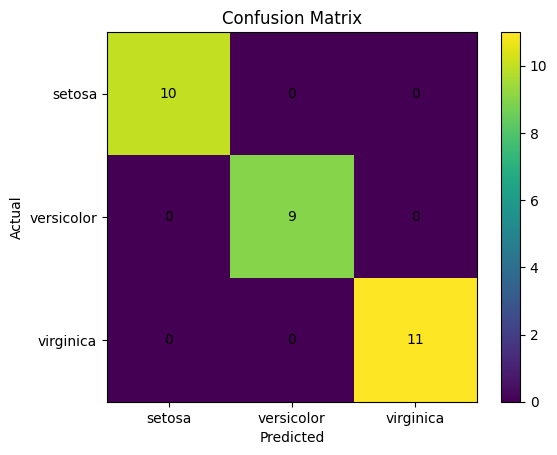


ACTUAL vs PREDICTED (First 10)
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor

CLASS PROBABILITIES (First 5 Samples)
[[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]

LOGISTIC REGRESSION ACCURACY: 1.0


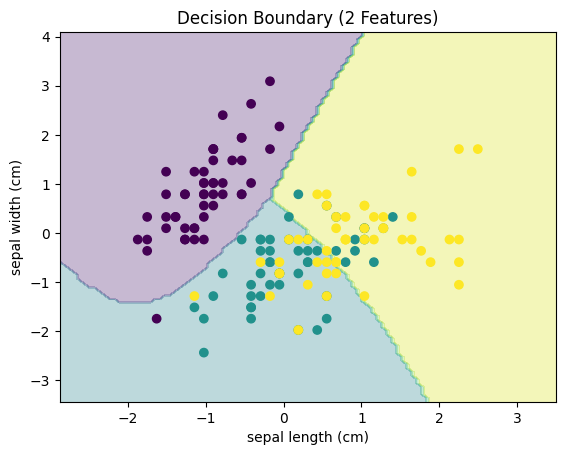

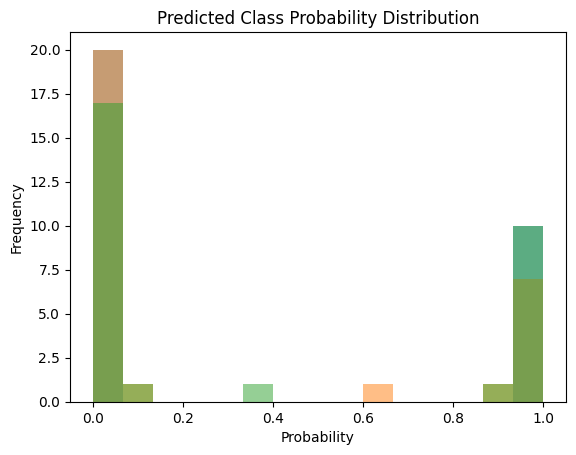

In [ ]:
print("SREENIDHI - 24BAD114")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

iris = load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["Species"] = y

print("DATASET SHAPE:", df.shape)
print("\nFIRST 5 ROWS\n", df.head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nGAUSSIAN NAIVE BAYES PERFORMANCE")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1,2], target_names)
plt.yticks([0,1,2], target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nACTUAL vs PREDICTED (First 10)")
for i in range(10):
    print("Actual:", target_names[y_test[i]],
          "| Predicted:", target_names[y_pred[i]])

probabilities = gnb.predict_proba(X_test)

print("\nCLASS PROBABILITIES (First 5 Samples)")
print(probabilities[:5])

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("\nLOGISTIC REGRESSION ACCURACY:",
      accuracy_score(y_test, y_pred_lr))

X_two = X_scaled[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42)

gnb2 = GaussianNB()
gnb2.fit(X_train2, y_train2)

x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Decision Boundary (2 Features)")
plt.show()

plt.figure()
for i in range(3):
    plt.hist(probabilities[:, i], alpha=0.5, bins=15)

plt.title("Predicted Class Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()